In [1]:
import jax
import jax.numpy as jnp
import fmmax
import numpy as np
import matplotlib.pyplot as plt

print("JAX version:", jax.__version__)
print("JAX devices:", jax.devices())
print("fmmax version:", fmmax.__version__)

JAX version: 0.10.2
JAX devices: [CpuDevice(id=0)]
fmmax version: v1.7.1


In [2]:
import os
files = os.listdir('/Users/yeshudanbora/euv-rcwa-inverse/data/cxro')
print(files)

['tin.txt', 'cr.txt', 'mo.txt', 'cu.txt', 'si.txt']


In [3]:
with open('/Users/yeshudanbora/euv-rcwa-inverse/data/cxro/mo.txt') as f:
    for i, line in enumerate(f):
        print(line.rstrip())
        if i > 10:
            break

 Mo Density=10.22
 Wavelength (nm), Delta, Beta
  12.5  0.0615031272  0.00507026212
  12.5092793  0.0616292842  0.00507668313
  12.5185671  0.0617557094  0.00508311251
  12.5278587  0.0618823357  0.00508954842
  12.5371609  0.0620092303  0.00509599596
  12.5464678  0.0621363707  0.00510244863
  12.5557814  0.0622637235  0.00510891015
  12.5651035  0.062391337  0.00511538144
  12.5744314  0.0625192001  0.00512185832
  12.583765  0.0626472756  0.00512834406


In [4]:
import numpy as np

def load_cxro(material):
    """Load CXRO Henke table for a material. Returns wavelength (nm), delta, beta."""
    path = f'/Users/yeshudanbora/euv-rcwa-inverse/data/cxro/{material.lower()}.txt'
    data = np.loadtxt(path, skiprows=2)
    wavelength_nm = data[:, 0]
    delta = data[:, 1]
    beta = data[:, 2]
    return wavelength_nm, delta, beta

def get_n(material, wavelength_nm):
    """Return complex refractive index n = 1 - delta + i*beta at a given wavelength (nm).
    Linear interpolation between tabulated points."""
    wl, delta, beta = load_cxro(material)
    delta_interp = np.interp(wavelength_nm, wl, delta)
    beta_interp = np.interp(wavelength_nm, wl, beta)
    return 1 - delta_interp + 1j * beta_interp

# Sanity check at 13.5 nm
print(f"n(Mo, 13.5 nm) = {get_n('Mo', 13.5)}")
print(f"n(Si, 13.5 nm) = {get_n('Si', 13.5)}")

n(Mo, 13.5 nm) = (0.9237935006906505+0.0064354348722063595j)
n(Si, 13.5 nm) = (0.9990012732053363+0.0018264604884560475j)


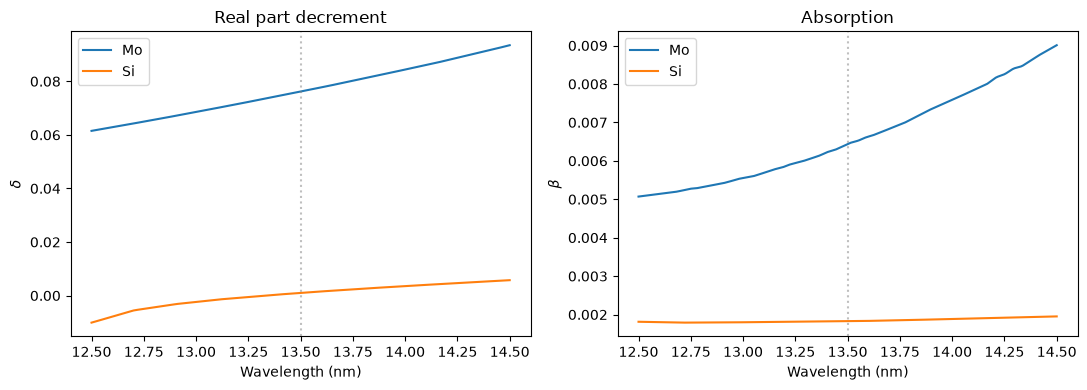

In [5]:
wl_grid = np.linspace(12.5, 14.5, 200)
n_mo = get_n('Mo', wl_grid)
n_si = get_n('Si', wl_grid)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(wl_grid, 1 - n_mo.real, label='Mo')
axes[0].plot(wl_grid, 1 - n_si.real, label='Si')
axes[0].set_xlabel('Wavelength (nm)')
axes[0].set_ylabel(r'$\delta$')
axes[0].axvline(13.5, color='gray', linestyle=':', alpha=0.5)
axes[0].legend()
axes[0].set_title('Real part decrement')

axes[1].plot(wl_grid, n_mo.imag, label='Mo')
axes[1].plot(wl_grid, n_si.imag, label='Si')
axes[1].set_xlabel('Wavelength (nm)')
axes[1].set_ylabel(r'$\beta$')
axes[1].axvline(13.5, color='gray', linestyle=':', alpha=0.5)
axes[1].legend()
axes[1].set_title('Absorption')

plt.tight_layout()
plt.show()

In [6]:
import fmmax

# Stack parameters (Schiavone 2001 / modern EUV multilayer)
D_MO = 2.78    # Mo thickness in nm
D_SI = 4.17    # Si thickness in nm
N_BILAYERS = 40
WL_CENTER = 13.5   # design wavelength (nm)
ANGLE_DEG = 6.0    # oblique incidence 

# Print fmmax module contents so we can see the API
print(dir(fmmax))

['Expansion', 'Formulation', 'LatticeVectors', 'LayerSolveResult', 'PMLParams', 'ScatteringMatrix', 'Truncation', 'X', 'Y', '_X', '_Y', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_basis', '_fft', '_fields', '_fmm', '_fmm_result', '_scattering', '_utils', 'amplitude_poynting_flux', 'amplitudes_for_fields', 'amplitudes_for_source', 'angular_frequency_for_wavelength', 'append_layer', 'apply_uniaxial_pml', 'basis', 'beams', 'brillouin_zone_in_plane_wavevector', 'broadcast_result', 'colocate_amplitudes', 'dirac_delta_source', 'directional_poynting_flux', 'eig', 'eigenmode_poynting_flux', 'eigensolve_anisotropic_media', 'eigensolve_general_anisotropic_media', 'eigensolve_isotropic_media', 'farfield', 'farfield_integrated_flux', 'farfield_profile', 'fft', 'fields', 'fields_from_wave_amplitudes', 'fields_on_coordinates', 'fields_on_grid', 'fmm', 'fmm_matrices', 'gaussian_source', 'generate_expansion', 'i

In [7]:
import tmm
print("tmm version:", tmm.__version__ if hasattr(tmm, '__version__') else 'installed')

tmm version: installed


In [8]:
# Single-wavelength benchmark at 13.5 nm
n_air = 1.0 + 0.0j
n_mo = get_n('Mo', 13.5)
n_si = get_n('Si', 13.5)

# Stack: air | 40x [Mo(2.78nm) / Si(4.17nm)] | Si substrate
n_list = [n_air]
d_list = [np.inf]

for _ in range(40):
    n_list.append(n_mo)
    d_list.append(2.78)
    n_list.append(n_si)
    d_list.append(4.17)

n_list.append(n_si)  # semi-infinite Si substrate
d_list.append(np.inf)

angle_rad = np.deg2rad(6.0)
wavelength = 13.5

result = tmm.coh_tmm('s', n_list, d_list, angle_rad, wavelength)
print(f"Reflectance at 13.5 nm, 6° TE: {result['R']:.4f}")
print(f"Expected: 0.65 - 0.70")

Reflectance at 13.5 nm, 6° TE: 0.7430
Expected: 0.65 - 0.70


Peak R: 0.7430 at 13.505 nm
FWHM: 0.623 nm


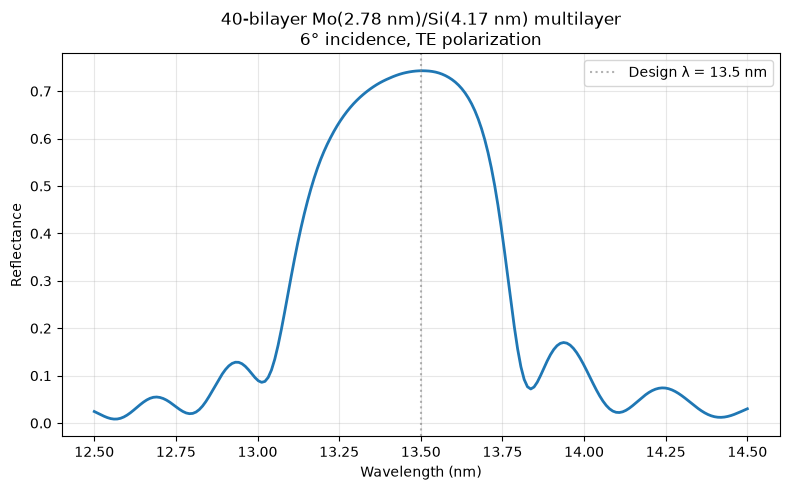

In [9]:
wl_grid = np.linspace(12.5, 14.5, 200)
R_grid = np.zeros_like(wl_grid)

for i, wl in enumerate(wl_grid):
    n_mo_wl = get_n('Mo', wl)
    n_si_wl = get_n('Si', wl)
    
    n_list = [1.0 + 0.0j]
    d_list = [np.inf]
    for _ in range(40):
        n_list.append(n_mo_wl)
        d_list.append(2.78)
        n_list.append(n_si_wl)
        d_list.append(4.17)
    n_list.append(n_si_wl)
    d_list.append(np.inf)
    
    result = tmm.coh_tmm('s', n_list, d_list, angle_rad, wl)
    R_grid[i] = result['R']

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(wl_grid, R_grid, linewidth=2)
ax.axvline(13.5, color='gray', linestyle=':', alpha=0.6, label='Design λ = 13.5 nm')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Reflectance')
ax.set_title('40-bilayer Mo(2.78 nm)/Si(4.17 nm) multilayer\n6° incidence, TE polarization')
ax.grid(alpha=0.3)
ax.legend()

# Compute peak and FWHM
peak_R = R_grid.max()
peak_wl = wl_grid[R_grid.argmax()]
half_max = peak_R / 2
above_half = wl_grid[R_grid >= half_max]
fwhm = above_half.max() - above_half.min() if len(above_half) > 0 else float('nan')

print(f"Peak R: {peak_R:.4f} at {peak_wl:.3f} nm")
print(f"FWHM: {fwhm:.3f} nm")

plt.tight_layout()
plt.show()

N=5: R = 0.1121
N=10: R = 0.3242
N=20: R = 0.6184
N=30: R = 0.7168
N=40: R = 0.7430
N=50: R = 0.7496
N=60: R = 0.7513
N=80: R = 0.7518


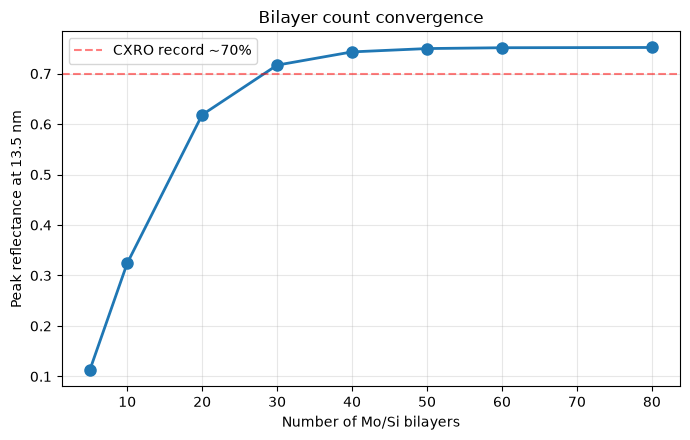

In [10]:
n_counts = [5, 10, 20, 30, 40, 50, 60, 80]
peak_R_by_N = []

for N in n_counts:
    n_mo_wl = get_n('Mo', 13.5)
    n_si_wl = get_n('Si', 13.5)
    n_list = [1.0 + 0.0j]
    d_list = [np.inf]
    for _ in range(N):
        n_list.append(n_mo_wl)
        d_list.append(2.78)
        n_list.append(n_si_wl)
        d_list.append(4.17)
    n_list.append(n_si_wl)
    d_list.append(np.inf)
    result = tmm.coh_tmm('s', n_list, d_list, angle_rad, 13.5)
    peak_R_by_N.append(result['R'])
    print(f"N={N}: R = {result['R']:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(n_counts, peak_R_by_N, 'o-', linewidth=2, markersize=8)
ax.axhline(0.70, color='red', linestyle='--', alpha=0.5, label='CXRO record ~70%')
ax.set_xlabel('Number of Mo/Si bilayers')
ax.set_ylabel('Peak reflectance at 13.5 nm')
ax.set_title('Bilayer count convergence')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**part 2: patterned absorber.**

In [11]:
pip show fmmax

Name: fmmax
Version: 1.7.1
Summary: Fourier modal method with Jax
Home-page: 
Author: 
Author-email: Martin Schubert <mfschubert@gmail.com>, Alec Hammond <alec.m.hammond@gmail.com>
License-Expression: MIT
Location: /opt/miniconda3/envs/rcwa/lib/python3.11/site-packages
Requires: jax, jaxlib, numpy
Required-by: 


/opt/miniconda3/envs/rcwa/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.


In [12]:
print(f"n(Cr, 13.5 nm) = {get_n('Cr', 13.5)}")

n(Cr, 13.5 nm) = (0.9248776105314082+0.043694531353541656j)


In [13]:
# part 2: 50 nm Cr blanket absorber on 40-bilayer Mo/Si multilayer.
# Uses TMM (planar, no grating yet).

def multilayer_stack_with_absorber(
    wavelength_nm,
    absorber_material='Cr',
    absorber_thickness_nm=50.0,
    n_bilayers=40,
    d_mo_nm=2.78,
    d_si_nm=4.17,
    angle_deg=6.0,
    polarization='s',
):
    """Compute reflectance of: air | absorber | 40x[Mo/Si] | Si substrate."""
    n_air = 1.0 + 0.0j
    n_abs = get_n(absorber_material, wavelength_nm)
    n_mo = get_n('Mo', wavelength_nm)
    n_si = get_n('Si', wavelength_nm)
    
    n_list = [n_air]
    d_list = [np.inf]
    
    # Absorber layer on top
    if absorber_thickness_nm > 0:
        n_list.append(n_abs)
        d_list.append(absorber_thickness_nm)
    
    # 40 Mo/Si bilayers
    for _ in range(n_bilayers):
        n_list.append(n_mo)
        d_list.append(d_mo_nm)
        n_list.append(n_si)
        d_list.append(d_si_nm)
    
    # Si substrate (semi-infinite)
    n_list.append(n_si)
    d_list.append(np.inf)
    
    angle_rad = np.deg2rad(angle_deg)
    result = tmm.coh_tmm(polarization, n_list, d_list, angle_rad, wavelength_nm)
    return result['R']

# Compare: multilayer alone vs. multilayer + 50 nm Cr blanket at 13.5 nm
R_bare = multilayer_stack_with_absorber(13.5, absorber_thickness_nm=0.0)
R_with_cr = multilayer_stack_with_absorber(13.5, absorber_material='Cr', absorber_thickness_nm=50.0)

print(f"Bare multilayer R at 13.5 nm:            {R_bare:.4f}")
print(f"With 50 nm Cr absorber R at 13.5 nm:     {R_with_cr:.4f}")
print(f"Contrast (bare - absorbed):              {R_bare - R_with_cr:.4f}")
print(f"Contrast ratio (with/bare):              {R_with_cr/R_bare*100:.1f}%")

Bare multilayer R at 13.5 nm:            0.7430
With 50 nm Cr absorber R at 13.5 nm:     0.0151
Contrast (bare - absorbed):              0.7279
Contrast ratio (with/bare):              2.0%


In [14]:
for mat in ['Mo', 'Si', 'Cr', 'TiN', 'Cu']:
    n = get_n(mat, 13.5)
    print(f"n({mat}, 13.5 nm) = {n:.4f}, β = {n.imag:.4f}")

n(Mo, 13.5 nm) = 0.9238+0.0064j, β = 0.0064
n(Si, 13.5 nm) = 0.9990+0.0018j, β = 0.0018
n(Cr, 13.5 nm) = 0.9249+0.0437j, β = 0.0437
n(TiN, 13.5 nm) = 0.9349+0.0192j, β = 0.0192
n(Cu, 13.5 nm) = 0.9624+0.0614j, β = 0.0614


In [15]:
# Rebuild results dict
absorber_materials = ['Cr', 'Mo', 'TiN', 'Cu']
thickness_grid_nm = np.linspace(0.0, 120.0, 121)
R_bare = multilayer_stack_with_absorber(13.5, absorber_thickness_nm=0.0)

results = {}
for mat in absorber_materials:
    R_arr = np.zeros_like(thickness_grid_nm)
    for i, t in enumerate(thickness_grid_nm):
        R_arr[i] = multilayer_stack_with_absorber(
            wavelength_nm=13.5,
            absorber_material=mat,
            absorber_thickness_nm=t,
        )
    contrast = (R_bare - R_arr) / R_bare * 100
    results[mat] = (R_arr, contrast)

print("results dict rebuilt with keys:", list(results.keys()))

results dict rebuilt with keys: ['Cr', 'Mo', 'TiN', 'Cu']


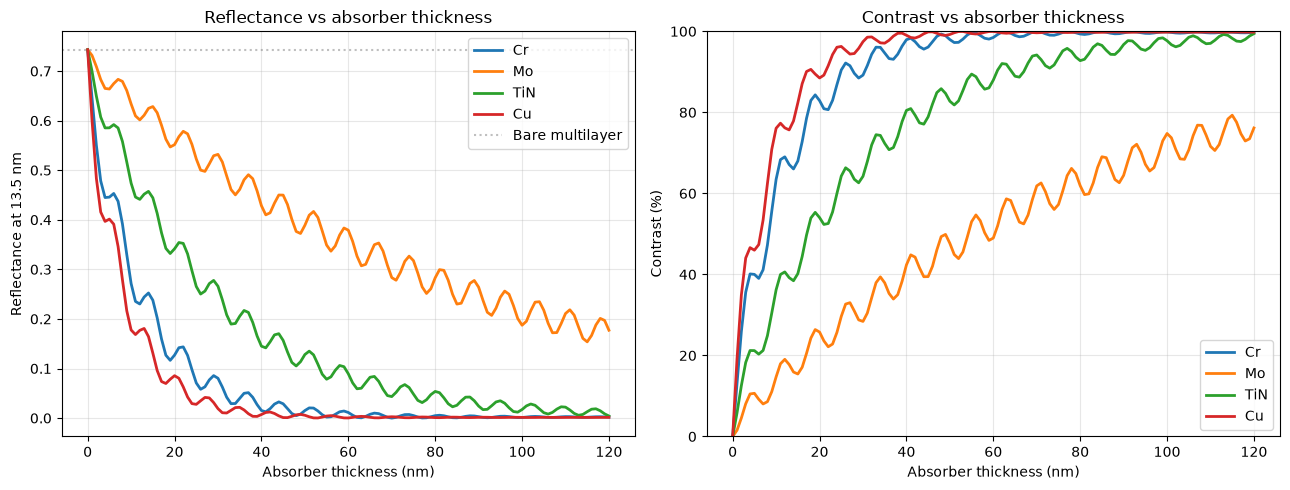

In [16]:
# Schiavone Fig. 2: reflectance and contrast vs. absorber thickness
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for mat, (R_arr, contrast) in results.items():
    axes[0].plot(thickness_grid_nm, R_arr, label=mat, linewidth=2)
    axes[1].plot(thickness_grid_nm, contrast, label=mat, linewidth=2)

axes[0].set_xlabel('Absorber thickness (nm)')
axes[0].set_ylabel('Reflectance at 13.5 nm')
axes[0].set_title('Reflectance vs absorber thickness')
axes[0].axhline(R_bare, color='gray', linestyle=':', alpha=0.5, label='Bare multilayer')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Absorber thickness (nm)')
axes[1].set_ylabel('Contrast (%)')
axes[1].set_title('Contrast vs absorber thickness')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

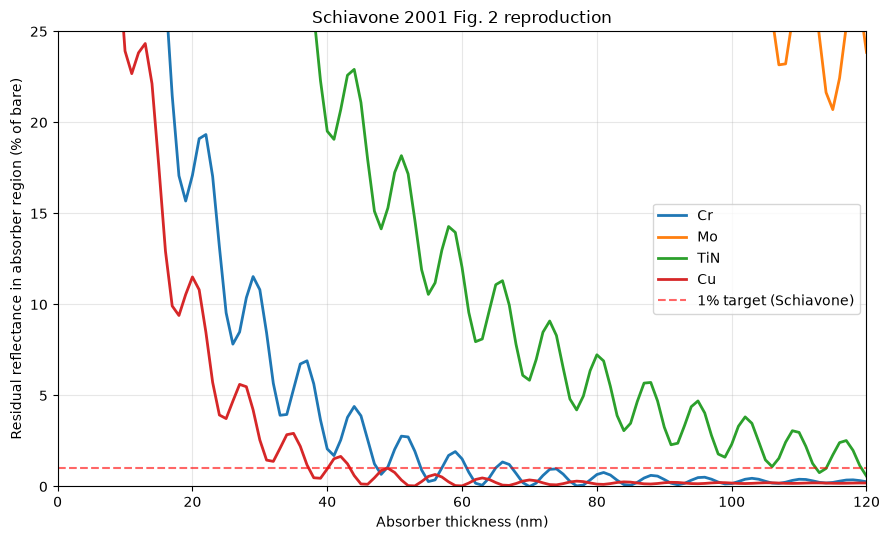

In [17]:
# Schiavone 2001 Fig. 2 reproduction — her convention:
# y-axis = residual reflectance in absorber region as % of bare multilayer
fig, ax = plt.subplots(figsize=(9, 5.5))

for mat, (R_arr, _) in results.items():
    schiavone_contrast = (R_arr / R_bare) * 100
    ax.plot(thickness_grid_nm, schiavone_contrast, label=mat, linewidth=2)

ax.axhline(1.0, color='red', linestyle='--', alpha=0.6, label='1% target (Schiavone)')
ax.set_xlabel('Absorber thickness (nm)')
ax.set_ylabel('Residual reflectance in absorber region (% of bare)')
ax.set_title('Schiavone 2001 Fig. 2 reproduction')
ax.set_ylim(0, 25)
ax.set_xlim(0, 120)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
from scipy.signal import find_peaks

print("\nFirst substantial local reflectance minimum (Schiavone-style optimum):")
for mat, (R_arr, contrast) in results.items():
    # Find local minima by finding peaks in -R, with prominence to reject noise
    inverted = -R_arr
    peaks, props = find_peaks(inverted, prominence=0.01)  # 1% prominence threshold
    if len(peaks) > 0:
        idx = peaks[0]
        residual_pct = (R_arr[idx] / R_bare) * 100
        print(f"  {mat}: {thickness_grid_nm[idx]:.0f} nm → R = {R_arr[idx]:.4f} "
              f"({residual_pct:.1f}% of bare)")
    else:
        print(f"  {mat}: no prominent local min")


First substantial local reflectance minimum (Schiavone-style optimum):
  Cr: 12 nm → R = 0.2301 (31.0% of bare)
  Mo: 5 nm → R = 0.6638 (89.3% of bare)
  TiN: 12 nm → R = 0.4412 (59.4% of bare)
  Cu: 11 nm → R = 0.1685 (22.7% of bare)


In [19]:
print("\nThickness where residual reflectance first drops below 1% target:")
for mat, (R_arr, _) in results.items():
    residual_pct = (R_arr / R_bare) * 100
    below_1pct = np.where(residual_pct < 1.0)[0]
    if len(below_1pct) > 0:
        t = thickness_grid_nm[below_1pct[0]]
        print(f"  {mat}: {t:.0f} nm")
    else:
        print(f"  {mat}: never reaches 1% in 0–120 nm range")


Thickness where residual reflectance first drops below 1% target:
  Cr: 48 nm
  Mo: never reaches 1% in 0–120 nm range
  TiN: 113 nm
  Cu: 38 nm


**sub goal 3:**

In [25]:
# Sub-goal 3, step 1: fmmax grating sanity check.
# Set up a "grating" that's actually a full Cr blanket to reduce to TMM answer.
# Multilayer + blanket Cr should give same R as TMM.

from fmmax import basis, fmm, scattering, utils

def eps_from_n(n_complex):
    """Convert refractive index to permittivity: eps = n^2."""
    return jnp.asarray(n_complex ** 2, dtype=jnp.complex64)

# Patched fmmax function with correct kx convention
def fmmax_multilayer_grating(
    wavelength_nm=13.5,
    pitch_nm=840.0,
    line_width_nm=280.0,
    cr_thickness_nm=50.0,
    n_bilayers=40,
    d_mo_nm=2.78,
    d_si_nm=4.17,
    angle_deg=6.0,
    resolution_nm=4.0,
    approximate_num_terms=25,
    force_blanket=False,  # for sanity checks
):
    n_air = 1.0 + 0.0j
    n_cr = get_n('Cr', wavelength_nm)
    n_mo = get_n('Mo', wavelength_nm)
    n_si = get_n('Si', wavelength_nm)
    
    eps_air = jnp.asarray(n_air**2, dtype=jnp.complex64)
    eps_cr = jnp.asarray(n_cr**2, dtype=jnp.complex64)
    eps_mo = jnp.asarray(n_mo**2, dtype=jnp.complex64)
    eps_si = jnp.asarray(n_si**2, dtype=jnp.complex64)
    
    nx = int(pitch_nm / resolution_nm)
    ny = nx
    x_nm = jnp.linspace(-pitch_nm/2, pitch_nm/2, nx, endpoint=False)
    x_grid, _ = jnp.meshgrid(x_nm, x_nm, indexing='ij')
    
    # Grating pattern
    density_cr = (jnp.abs(x_grid) <= line_width_nm / 2).astype(jnp.float32)
    if force_blanket:
        density_cr = jnp.ones_like(density_cr)
    
    eps_grating = utils.interpolate_permittivity(
        permittivity_solid=eps_cr,
        permittivity_void=eps_air,
        density=density_cr,
    )
    
    def uniform(eps_val):
        return jnp.ones((nx, ny), dtype=jnp.complex64) * eps_val
    
    permittivities = [uniform(eps_air), eps_grating]
    thicknesses = [jnp.asarray(0.0), jnp.asarray(cr_thickness_nm)]
    for _ in range(n_bilayers):
        permittivities.append(uniform(eps_mo))
        thicknesses.append(jnp.asarray(d_mo_nm))
        permittivities.append(uniform(eps_si))
        thicknesses.append(jnp.asarray(d_si_nm))
    permittivities.append(uniform(eps_si))
    thicknesses.append(jnp.asarray(0.0))
    
    # Correct kx convention: k0 * sin(theta)
    k0 = 2 * jnp.pi / wavelength_nm
    kx = k0 * jnp.sin(jnp.deg2rad(angle_deg))
    in_plane_wavevector = jnp.asarray([kx, 0.0])
    
    primitive_lattice_vectors = basis.LatticeVectors(
        u=jnp.asarray([pitch_nm, 0.0]),
        v=jnp.asarray([0.0, pitch_nm]),
    )
    expansion = basis.generate_expansion(
        primitive_lattice_vectors=primitive_lattice_vectors,
        approximate_num_terms=approximate_num_terms,
        truncation=basis.Truncation.CIRCULAR,
    )
    layer_solve_results = [
        fmm.eigensolve_isotropic_media(
            wavelength=jnp.asarray(wavelength_nm),
            in_plane_wavevector=in_plane_wavevector,
            primitive_lattice_vectors=primitive_lattice_vectors,
            permittivity=p,
            expansion=expansion,
            formulation=fmm.Formulation.FFT,
        )
        for p in permittivities
    ]
    s_matrix = scattering.stack_s_matrix(
        layer_solve_results=layer_solve_results,
        layer_thicknesses=thicknesses,
    )
    
    n = expansion.num_terms
    R_te = float(jnp.abs(s_matrix.s21[0, 0])**2)
    R_tm = float(jnp.abs(s_matrix.s21[n, n])**2)
    return R_te, R_tm, n

# Sanity check 1: Cr blanket
print("=== Sanity check 1: Cr blanket, 6°, 50 nm ===")
R_te, R_tm, nt = fmmax_multilayer_grating(cr_thickness_nm=50.0, force_blanket=True)
print(f"fmmax: R_TE = {R_te:.4f}, R_TM = {R_tm:.4f}  ({nt} Fourier terms)")
print(f"TMM:   R    = 0.0151")
print(f"Match: {'YES' if abs(R_te - 0.0151) < 0.002 else 'NO'}")

# Sanity check 2: no absorber (bare multilayer)
print("\n=== Sanity check 2: bare multilayer, 6° ===")
R_te, R_tm, nt = fmmax_multilayer_grating(cr_thickness_nm=0.0, force_blanket=True)
print(f"fmmax: R_TE = {R_te:.4f}, R_TM = {R_tm:.4f}")
print(f"TMM:   R    = 0.7430")

# Sanity check 3: real grating (280 nm Cr line / 560 nm space, 50 nm thick)
print("\n=== Sanity check 3: real Cr grating, 6° ===")
R_te, R_tm, nt = fmmax_multilayer_grating(cr_thickness_nm=50.0, force_blanket=False)
print(f"fmmax: R_TE = {R_te:.4f}, R_TM = {R_tm:.4f}")
print(f"Expected: somewhere between blanket (0.0151) and bare (0.7430)")
print(f"         weighted roughly by (line/pitch, space/pitch) = (1/3, 2/3)")
print(f"         very rough guess: 0.0151*(1/3) + 0.7430*(2/3) = {0.0151/3 + 0.7430*2/3:.4f}")

=== Sanity check 1: Cr blanket, 6°, 50 nm ===
fmmax: R_TE = 0.0151, R_TM = 0.0148  (21 Fourier terms)
TMM:   R    = 0.0151
Match: YES

=== Sanity check 2: bare multilayer, 6° ===
fmmax: R_TE = 0.7430, R_TM = 0.7355
TMM:   R    = 0.7430

=== Sanity check 3: real Cr grating, 6° ===
fmmax: R_TE = 0.2471, R_TM = 0.2446
Expected: somewhere between blanket (0.0151) and bare (0.7430)
         weighted roughly by (line/pitch, space/pitch) = (1/3, 2/3)
         very rough guess: 0.0151*(1/3) + 0.7430*(2/3) = 0.5004


In [28]:
from fmmax import fields

def fmmax_near_field_intensity(
    wavelength_nm=13.5,
    pitch_nm=840.0,
    line_width_nm=280.0,
    cr_thickness_nm=50.0,
    n_bilayers=40,
    d_mo_nm=2.78,
    d_si_nm=4.17,
    angle_deg=6.0,
    resolution_nm=4.0,
    approximate_num_terms=25,
    n_x_field_points=200,
    air_above_nm=20.0,
    n_z_air_above=8,
):
    """Compute near-field intensity |E|^2 above the Cr grating."""
    n_air = 1.0 + 0.0j
    n_cr = get_n('Cr', wavelength_nm)
    n_mo = get_n('Mo', wavelength_nm)
    n_si = get_n('Si', wavelength_nm)
    eps_air = jnp.asarray(n_air**2, dtype=jnp.complex64)
    eps_cr = jnp.asarray(n_cr**2, dtype=jnp.complex64)
    eps_mo = jnp.asarray(n_mo**2, dtype=jnp.complex64)
    eps_si = jnp.asarray(n_si**2, dtype=jnp.complex64)
    
    nx = int(pitch_nm / resolution_nm)
    ny = nx
    x_nm_grid = jnp.linspace(-pitch_nm/2, pitch_nm/2, nx, endpoint=False)
    x_grid, _ = jnp.meshgrid(x_nm_grid, x_nm_grid, indexing='ij')
    density_cr = (jnp.abs(x_grid) <= line_width_nm / 2).astype(jnp.float32)
    
    eps_grating = utils.interpolate_permittivity(
        permittivity_solid=eps_cr,
        permittivity_void=eps_air,
        density=density_cr,
    )
    def uniform(eps_val):
        return jnp.ones((nx, ny), dtype=jnp.complex64) * eps_val
    
    # Stack: air above (thick, we'll probe fields in this layer) | Cr grating | 40x MoSi | Si substrate
    permittivities = [uniform(eps_air), eps_grating]
    thicknesses = [jnp.asarray(air_above_nm), jnp.asarray(cr_thickness_nm)]
    for _ in range(n_bilayers):
        permittivities.append(uniform(eps_mo))
        thicknesses.append(jnp.asarray(d_mo_nm))
        permittivities.append(uniform(eps_si))
        thicknesses.append(jnp.asarray(d_si_nm))
    permittivities.append(uniform(eps_si))
    thicknesses.append(jnp.asarray(0.0))
    
    k0 = 2 * jnp.pi / wavelength_nm
    kx = k0 * jnp.sin(jnp.deg2rad(angle_deg))
    in_plane_wavevector = jnp.asarray([kx, 0.0])
    
    primitive_lattice_vectors = basis.LatticeVectors(
        u=jnp.asarray([pitch_nm, 0.0]),
        v=jnp.asarray([0.0, pitch_nm]),
    )
    expansion = basis.generate_expansion(
        primitive_lattice_vectors=primitive_lattice_vectors,
        approximate_num_terms=approximate_num_terms,
        truncation=basis.Truncation.CIRCULAR,
    )
    layer_solve_results = [
        fmm.eigensolve_isotropic_media(
            wavelength=jnp.asarray(wavelength_nm),
            in_plane_wavevector=in_plane_wavevector,
            primitive_lattice_vectors=primitive_lattice_vectors,
            permittivity=p,
            expansion=expansion,
            formulation=fmm.Formulation.FFT,
        )
        for p in permittivities
    ]
    
    s_matrices_interior = scattering.stack_s_matrices_interior(
        layer_solve_results=layer_solve_results,
        layer_thicknesses=thicknesses,
    )
    
    # Incident TE plane wave, zeroth order
    n_terms = expansion.num_terms
    incident_amp = jnp.zeros((2 * n_terms, 1), dtype=jnp.complex64)
    incident_amp = incident_amp.at[0, 0].set(1.0 + 0.0j)
    zero_amp = jnp.zeros_like(incident_amp)
    
    # Get amplitudes at each layer interior (fixed: fields module)
    amplitudes_interior = fields.stack_amplitudes_interior(
        s_matrices_interior=s_matrices_interior,
        forward_amplitude_0_start=incident_amp,
        backward_amplitude_N_end=zero_amp,
    )
    
    # z resolution per layer: many in the air above, minimal elsewhere
    layer_znum = [n_z_air_above, 2] + [1] * (2 * n_bilayers) + [1]
    
    # 1D probe line at y=0
    x_eval = jnp.linspace(-pitch_nm/2, pitch_nm/2, n_x_field_points, endpoint=False)
    y_eval = jnp.zeros_like(x_eval)
    
    ef, hf, (x_out, y_out, z_out) = fields.stack_fields_3d_on_coordinates(
        amplitudes_interior=amplitudes_interior,
        layer_solve_results=layer_solve_results,
        layer_thicknesses=thicknesses,
        layer_znum=layer_znum,
        x=x_eval,
        y=y_eval,
    )
    
    return ef, hf, x_out, z_out, density_cr[:, 0]

# Run and inspect shapes first
print("Computing near-field for 50 nm Cr grating...")
ef, hf, x_out, z_out, cr_profile = fmmax_near_field_intensity(
    cr_thickness_nm=50.0,
    approximate_num_terms=50,
)
print(f"ef type: {type(ef)}")
if isinstance(ef, tuple):
    print(f"ef is tuple of length {len(ef)}, first element shape: {ef[0].shape}")
else:
    print(f"ef shape: {ef.shape}")
print(f"x_out shape: {x_out.shape}")
print(f"z_out shape: {z_out.shape}")
print(f"z range: {float(z_out.min()):.2f} to {float(z_out.max()):.2f}")

Computing near-field for 50 nm Cr grating...
ef type: <class 'jaxlib._jax.ArrayImpl'>
ef shape: (3, 200, 91, 1)
x_out shape: (200,)
z_out shape: (91,)
z range: 0.00 to 348.00


Selected z_out[7] = 20.00 nm (target: 20 nm, top of Cr)


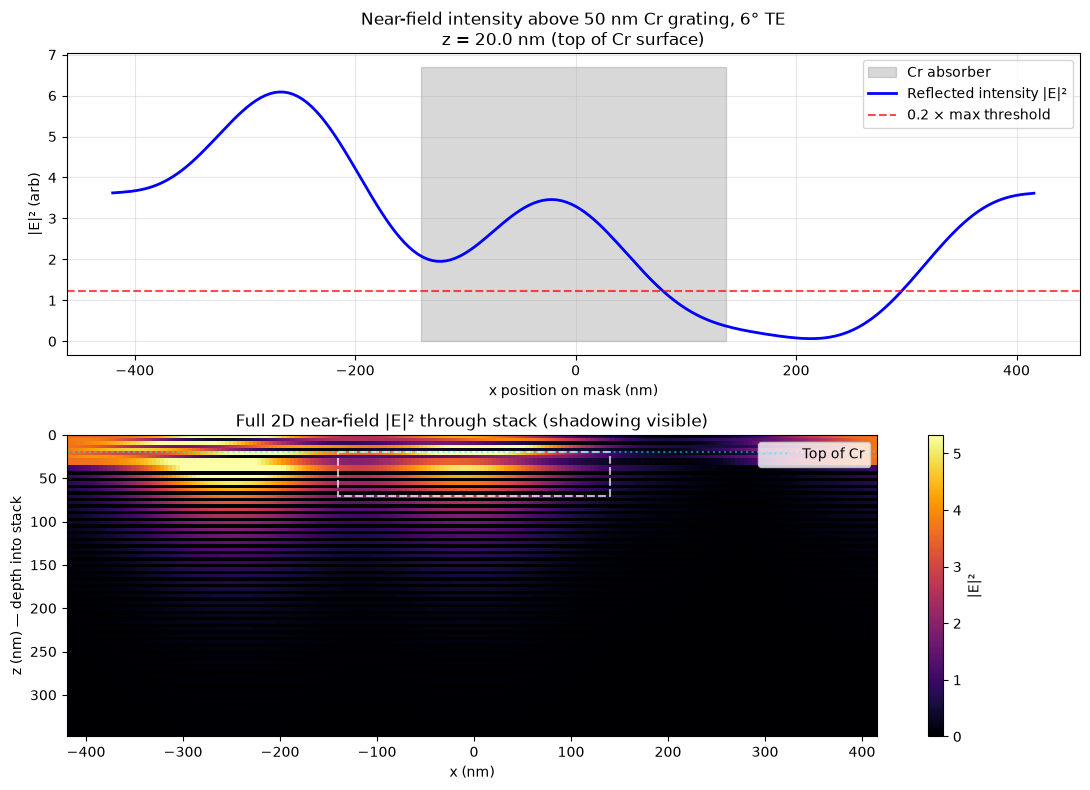


Intensity peak (over open space): 6.0869
Intensity valley (over Cr line):  0.0651
Peak-to-valley contrast:          93.5×


In [29]:
# Extract intensity and plot
# ef shape: (3 components, n_x, n_z, 1 amplitude)
Ex = ef[0, :, :, 0]  # (200, 91)
Ey = ef[1, :, :, 0]
Ez = ef[2, :, :, 0]
intensity_2d = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2  # (n_x, n_z)

# Find z-index closest to top of Cr grating (z = air_above_nm = 20 nm)
z_np = np.array(z_out)
top_of_cr_idx = np.argmin(np.abs(z_np - 20.0))
print(f"Selected z_out[{top_of_cr_idx}] = {z_np[top_of_cr_idx]:.2f} nm (target: 20 nm, top of Cr)")

# 1D intensity slice at top of Cr
intensity_1d = intensity_2d[:, top_of_cr_idx]

# Cr profile (mask scale)
pitch_nm = 840.0
line_width_nm = 280.0
cr_x_mask = np.linspace(-pitch_nm/2, pitch_nm/2, len(cr_profile), endpoint=False)

fig, axes = plt.subplots(2, 1, figsize=(11, 8))

# Panel 1: 1D intensity at top of Cr surface
ax = axes[0]
ax.fill_between(cr_x_mask, 0, intensity_1d.max()*1.1,
                where=np.array(cr_profile) > 0.5,
                color='gray', alpha=0.3, label='Cr absorber')
ax.plot(np.array(x_out), intensity_1d, 'b-', linewidth=2, label='Reflected intensity |E|²')
ax.axhline(0.2 * intensity_1d.max(), color='red', linestyle='--',
           alpha=0.7, label='0.2 × max threshold')
ax.set_xlabel('x position on mask (nm)')
ax.set_ylabel('|E|² (arb)')
ax.set_title(f'Near-field intensity above 50 nm Cr grating, 6° TE\n'
             f'z = {z_np[top_of_cr_idx]:.1f} nm (top of Cr surface)')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

# Panel 2: 2D intensity map through full stack — the hero shadowing image
ax = axes[1]
extent = [float(x_out[0]), float(x_out[-1]), float(z_out[-1]), float(z_out[0])]
im = ax.imshow(intensity_2d.T, extent=extent, aspect='auto', cmap='inferno',
               vmin=0, vmax=np.percentile(intensity_2d, 99))
plt.colorbar(im, ax=ax, label='|E|²')
# Overlay Cr region as outline
cr_z_top = 20.0
cr_z_bot = 20.0 + 50.0
for x_start in [-140]:  # left edge of Cr line (280/2 = 140)
    ax.plot([x_start, x_start+280, x_start+280, x_start, x_start],
            [cr_z_top, cr_z_top, cr_z_bot, cr_z_bot, cr_z_top],
            'w--', linewidth=1.5, alpha=0.7)
ax.axhline(20.0, color='cyan', linestyle=':', alpha=0.5, label='Top of Cr')
ax.set_xlabel('x (nm)')
ax.set_ylabel('z (nm) — depth into stack')
ax.set_title('Full 2D near-field |E|² through stack (shadowing visible)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Report peak-to-valley
peak = intensity_1d.max()
valley = intensity_1d.min()
print(f"\nIntensity peak (over open space): {peak:.4f}")
print(f"Intensity valley (over Cr line):  {valley:.4f}")
print(f"Peak-to-valley contrast:          {peak/valley:.1f}×")

In [30]:
# Convergence test: does the intensity pattern change with Fourier order count?
for num_terms in [25, 50, 100, 150]:
    print(f"\n--- Fourier terms: {num_terms} ---")
    ef_t, hf_t, x_out_t, z_out_t, cr_prof_t = fmmax_near_field_intensity(
        cr_thickness_nm=50.0,
        approximate_num_terms=num_terms,
    )
    Ex_t, Ey_t, Ez_t = ef_t[0, :, :, 0], ef_t[1, :, :, 0], ef_t[2, :, :, 0]
    intens = np.abs(Ex_t)**2 + np.abs(Ey_t)**2 + np.abs(Ez_t)**2
    z_np_t = np.array(z_out_t)
    top_idx = np.argmin(np.abs(z_np_t - 20.0))
    intens_1d = intens[:, top_idx]
    x_np = np.array(x_out_t)
    # Find x position of intensity minimum inside Cr region (|x| < 140)
    cr_mask = np.abs(x_np) < 140
    if cr_mask.any():
        min_idx_in_cr = np.argmin(np.where(cr_mask, intens_1d, np.inf))
        print(f"  Min intensity inside Cr at x = {x_np[min_idx_in_cr]:.1f} nm, "
              f"|E|² = {intens_1d[min_idx_in_cr]:.4f}")
    # Also find global min in the whole 1D profile
    global_min_idx = np.argmin(intens_1d)
    print(f"  Global min at x = {x_np[global_min_idx]:.1f} nm, "
          f"|E|² = {intens_1d[global_min_idx]:.4f}")


--- Fourier terms: 25 ---
  Min intensity inside Cr at x = 12.6 nm, |E|² = 1.4633
  Global min at x = -365.4 nm, |E|² = 0.9794

--- Fourier terms: 50 ---
  Min intensity inside Cr at x = 138.6 nm, |E|² = 0.3559
  Global min at x = 214.2 nm, |E|² = 0.0651

--- Fourier terms: 100 ---
  Min intensity inside Cr at x = -138.6 nm, |E|² = 1.8558
  Global min at x = 247.8 nm, |E|² = 0.7212

--- Fourier terms: 150 ---
  Min intensity inside Cr at x = -138.6 nm, |E|² = 1.8816
  Global min at x = -285.6 nm, |E|² = 0.0133
